## Testing Methods in the `BrainPlotter` Class

This Jupyter Notebook serves as a platform to rigorously test the various methods included in the Python class `BrainPlotter` from the `clabtoolkit.visualizationtools` module. The tests are organized into the following sections for clarity and ease of navigation:

---

### Section 1: BrainPlotter - Brain Visualization with PyVista

* **🔷 1. [`BrainPlotter`](#brainplotter-class)**: Class for visualizing brain surfaces, tractograms, and point clouds
  * 🔸 1.1. [`__init__`](#brainplotter-init): Initialize the BrainPlotter with configuration file
  * 🔸 1.2. [`plot`](#brainplotter-plot): Plot brain objects with optional maps and views
  * 🔸 1.3. [`plot_hemispheres`](#brainplotter-plot_hemispheres): Plot brain hemispheres with multiple views
  * 🔸 1.4. [`plot_scene`](#brainplotter-plot_scene): Plot a scene with multiple objects and custom configurations
  * 🔸 1.5. [`list_available_view_names`](#brainplotter-list_available_view_names): List available view names for dynamic view selection
  * 🔸 1.6. [`list_available_layouts`](#brainplotter-list_available_layouts): Display available visualization layouts
  * 🔸 1.7. [`get_layout_details`](#brainplotter-get_layout_details): Get detailed information about a specific layout
  * 🔸 1.8. [`get_figure_config`](#brainplotter-get_figure_config): Get the current figure configuration settings
  * 🔸 1.9. [`list_available_themes`](#brainplotter-list_available_themes): Display all available themes with descriptions
  * 🔸 1.10. [`update_figure_config`](#brainplotter-update_figure_config): Update figure configuration parameters
  * 🔸 1.11. [`apply_theme`](#brainplotter-apply_theme): Apply predefined visual themes
  * 🔸 1.12. [`list_figure_config_options`](#brainplotter-list_figure_config_options): Display all available configuration parameters
  * 🔸 1.13. [`reset_figure_config`](#brainplotter-reset_figure_config): Reset figure configuration to default values
  * 🔸 1.14. [`save_config`](#brainplotter-save_config): Save current configuration to JSON file
  * 🔸 1.15. [`preview_theme`](#brainplotter-preview_theme): Preview a theme's parameters without applying

* **🔷 2. [Other methods](#visu-other_methods)**: Other visualization methods 
  * 🔸 2.1. [create_carpet_plot](#visu-create_carpet_plot): Create a carpet plot for brain structure time series data.
---

### Section 1: BrainPlotter - Brain Visualization with PyVista

<a id="brainplotter-class"></a>
* **🔷 1. [`BrainPlotter`](#brainplotter-class)**: Class for visualizing brain surfaces, tractograms, and point clouds

<a id="brainplotter-init"></a>
* 🔸 1.1. **`__init__`**: Initialize the BrainPlotter with configuration file
---


In [1]:
########################### Testing BrainPlotter __init__ ###########################
import clabtoolkit.visualizationtools as cltvis
import os

print("Test 1: Creating BrainPlotter with default configuration...")
plotter = cltvis.BrainPlotter()
print(f"Configuration file: {plotter.config_file}")
print("-------------------------------")
print(" ")

print("Test 2: Creating BrainPlotter with custom configuration file...")
# Assuming you have a custom config file
custom_config = '/path/to/custom_viz_views.json'
if os.path.exists(custom_config):
    plotter = cltvis.BrainPlotter(config_file=custom_config)
    print(f"Loaded custom configuration: {plotter.config_file}")
else:
    print("Custom config file not found, using default")
    plotter = cltvis.BrainPlotter()
print("-------------------------------")
print(" ")

print("Test 3: Creating BrainPlotter with dictionary configuration...")
config_dict = {
    'figure_conf': {
        'background_color': 'white',
        'title_font_color': 'black'
    }
}
plotter = cltvis.BrainPlotter(config_file=config_dict)
print(f"Background color: {plotter.figure_conf.get('background_color', 'default')}")
print("-------------------------------")


Test 1: Creating BrainPlotter with default configuration...
Configuration file: /home/yaleman/WorkProjects/GithubRepositories/Worktools/clabtoolkit/clabtoolkit/config/viz_views.json
-------------------------------
 
Test 2: Creating BrainPlotter with custom configuration file...
Custom config file not found, using default
-------------------------------
 
Test 3: Creating BrainPlotter with dictionary configuration...
Background color: white
-------------------------------


<a id="brainplotter-plot"></a>
* 🔸 1.2. **`plot`**: Plot brain objects with optional maps and views
---

In [1]:
########################### Testing plot ###########################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_dir = os.path.join(os.getenv('FREESURFER_HOME', '/opt/freesurfer'),'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')

print("Test 1: Simple plot with single view...")
plotter = cltvis.BrainPlotter()
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    colorbar=True,

)
print("Plot saved to /tmp/test_single_view.png")
print("-------------------------------")
print(" ")

print("Test 2: Plot with multiple views...")
plotter.plot(
    objs2plot=surf_lh,
    views=['lateral', 'medial', 'dorsal'],
    map_names='thickness',
    colormaps='jet',
    colorbar=True,
    save_path='/tmp/test_multi_view.png'
)
print("Plot saved to /tmp/test_multi_view.png")
print("-------------------------------")
print(" ")

print("Test 3: Plot with custom colormap limits...")
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    v_limits=(1.5, 3.5),
    colormaps='coolwarm',
    colorbar=True,
    save_path='/tmp/test_custom_limits.png'
)
print("Plot saved to /tmp/test_custom_limits.png")
print("-------------------------------")
print(" ")

print("Test 4: Plot with value range (outlier coloring)...")
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    v_range=(2.0, 3.0),  # Values outside this range will be gray
    range_color=(128, 128, 128, 255),
    colormaps='viridis',
    colorbar=True,
    save_path='/tmp/test_value_range.png'
)
print("Plot saved with outlier coloring")
print("-------------------------------")
print(" ")

print("Test 5: Plot with list of objects same map...")
plotter.plot(
    objs2plot=[surf_lh, surf_rh],
    views='dorsal',
    map_names='thickness',
    colorbar=True,
)
print("Plot saved with multiple objects")
print("-------------------------------")
print(" ")

print("Test 6: Plot a single object with multiple maps...")
plotter.plot(
    objs2plot=[[surf_lh, surf_rh]],
    views='dorsal',
    map_names=['thickness', 'sulc'],
    colormaps=['viridis', 'coolwarm'],
    colorbar=True,
)
print("------------------------------")
print(" ")

print("Test 7: Plot with multiple surfaces and multiple views..." )
plotter.plot(   
        objs2plot = [[surf_lh, surf_rh], surf_lh, surf_rh],
        map_names = "thickness",
        hemi_id = ["lh", "rh"],
        views  = ["6_views"],
        views_orientation  = "horizontal",
        colormaps= ["jet"], 
        notebook = False,
        use_opacity=True,
        colorbar = True,
        colorbar_style="individual",
        colorbar_position = "bottom",
    )

print("------------------------------")
print(" ")

print("Test 8: Plot shared colorbar .." )
plotter.plot(   
        objs2plot = [[surf_lh, surf_rh], surf_lh, surf_rh],
        map_names = "thickness",
        hemi_id = ["lh", "rh"],
        views  = ["6_views"],
        views_orientation  = "horizontal",
        colormaps= ["jet"], 
        notebook = False,
        use_opacity=True,
        colorbar = True,
        colorbar_style="shared",
        colorbar_position = "bottom",
    )

Test 1: Simple plot with single view...
Number of views: 1, Number of maps: 1, Number of objects: 1
Plot saved to /tmp/test_single_view.png
-------------------------------
 
Test 2: Plot with multiple views...
Number of views: 3, Number of maps: 1, Number of objects: 1
Figure saved to: /tmp/test_multi_view.png
Plot saved to /tmp/test_multi_view.png
-------------------------------
 
Test 3: Plot with custom colormap limits...
Number of views: 1, Number of maps: 1, Number of objects: 1
Figure saved to: /tmp/test_custom_limits.png
Plot saved to /tmp/test_custom_limits.png
-------------------------------
 
Test 4: Plot with value range (outlier coloring)...
Number of views: 1, Number of maps: 1, Number of objects: 1
Figure saved to: /tmp/test_value_range.png
Plot saved with outlier coloring
-------------------------------
 
Test 5: Plot with list of objects same map...
Number of views: 1, Number of maps: 1, Number of objects: 2
Plot saved with multiple objects
-----------------------------

<a id="brainplotter-plot_hemispheres"></a>
* 🔸 1.3. **`plot_hemispheres`**: Plot brain hemispheres with multiple views
---

In [2]:
########################### Testing plot_hemispheres ###########################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_dir = os.path.join(os.getenv('FREESURFER_HOME', '/opt/freesurfer'),'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')


plotter = cltvis.BrainPlotter()

print("Test 1: Plot hemispheres with lateral views...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    views='8_views',
    map_name='thickness',
    save_path='/tmp/hemispheres_8_views.png'
)
print("Saved to /tmp/hemispheres_8_views.png")
print("-------------------------------")
print(" ")

print("Test 2: Plot hemispheres with multiple views...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    map_name='thickness',
    views=['lateral', 'medial', 'dorsal', 'ventral'],
    colorbar=True,
)
print("-------------------------------")
print(" ")

print("Test 3: Plot with custom colormap and limits...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    map_name='thickness',
    views='lateral',
    vmin=2.0,
    vmax=3.5,
    colormap='coolwarm',
    colorbar=True,
    colorbar_title='Cortical Thickness (mm)',
    save_path='/tmp/hemispheres_custom.png'
)
print("Saved with custom colormap")
print("-------------------------------")
print(" ")

print("Test 4: Plot with value range highlighting...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    map_name='thickness',
    views='lateral',
    range_min=2.0,
    range_max=3.0,
    range_color=(200, 200, 200, 255),
    colormap='viridis',
    colorbar=True,
    save_path='/tmp/hemispheres_range.png'
)
print("Saved with value range highlighting")
print("-------------------------------")
print(" ")

print("Test 5: Plot without colorbar...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    map_name='thickness',
    views=['lateral', 'medial'],
    colorbar=False,
    save_path='/tmp/hemispheres_no_colorbar.png'
)
print("Saved without colorbar")
print("-------------------------------")
print(" ")

print("Test 6: Export to interactive HTML...")
plotter.plot_hemispheres(
    obj_lh=surf_lh,
    obj_rh=surf_rh,
    map_name='thickness',
    views='dorsal',
    use_opacity=False,
    colorbar=True,
    save_path='/tmp/hemispheres_interactive.html'
)
print("Saved interactive HTML")
print("-------------------------------")

print("Test 7: Plot shared colorbar .." )
plotter.plot_hemispheres(   
        obj_lh=surf_lh, obj_rh=surf_rh,
        views  = ["6_views"],
        colormap= "bwr",
        notebook = False,
        map_name = "curvature",
        colorbar = True,
        colorbar_position = "right",
        colorbar_title="Curvature") 

print("------------------------------")


Test 1: Plot hemispheres with lateral views...
Figure saved to: /tmp/hemispheres_8_views.png
Saved to /tmp/hemispheres_8_views.png
-------------------------------
 
Test 2: Plot hemispheres with multiple views...
-------------------------------
 
Test 3: Plot with custom colormap and limits...
Figure saved to: /tmp/hemispheres_custom.png
Saved with custom colormap
-------------------------------
 
Test 4: Plot with value range highlighting...
Figure saved to: /tmp/hemispheres_range.png
Saved with value range highlighting
-------------------------------
 
Test 5: Plot without colorbar...
Figure saved to: /tmp/hemispheres_no_colorbar.png
Saved without colorbar
-------------------------------
 
Test 6: Export to interactive HTML...
Figure saved to: /tmp/hemispheres_interactive.html
Saved interactive HTML
-------------------------------
Test 7: Plot shared colorbar ..
------------------------------


<a id="brainplotter-plot_scene"></a>
* 🔸 1.4. **`plot_scene`**: Plot a scene with multiple objects and custom configurations
---

In [ ]:
########################### Testing plot_scene ###########################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.tracttools as clttract
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_home = os.getenv('FREESURFER_HOME', '/opt/freesurfer')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')

# Loading some tracts
in_trk1 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodyc.display.trk")
in_trk2 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodypf.display.trk")

# Loading 2 tract objects with colors
tract_obj1 = clttract.Tractogram(in_trk1, color="#FF0000FF")
tract_obj2 = clttract.Tractogram(in_trk2, color="#0000FFFF")

## Initialize BrainPlotter
plotter = cltvis.BrainPlotter()

print("Test 1: Plot scene with multiple objects...")
scene_objects = [surf_lh, surf_rh]
plotter.plot_scene(
    scene_objects=scene_objects,
    views='dorsal',
    save_path='/tmp/scene_basic.png'
)
print("Saved basic scene")
print("-------------------------------")
print(" ")

print("Test 2: Plot scene with custom configuration...")
scene_config = {
    0: {  # Configuration for first object
        'map_name': 'default',
        'colormap': 'gray',
        'v_limits': (None, None),
        'v_range': (None, None),
        'opacity': 0.8
    },
    1: {  # Configuration for second object
        'map_name': 'default',
        'colormap': 'gray',
        'v_limits': (None, None),
        'v_range': (None, None),
        'opacity': 0.8
    }
}
plotter.plot_scene(
    scene_objects=scene_objects,
    scene_config=scene_config,
    views='dorsal',
    save_path='/tmp/scene_custom.png'
)
print("Saved scene with custom config")
print("-------------------------------")
print(" ")

print("Test 3: Plot scene with different opacities...")
scene_config = {
    0: {'opacity': 0.5},  # Semi-transparent
    1: {'opacity': 1.0}   # Fully opaque
}
plotter.plot_scene(
    scene_objects=scene_objects,
    scene_config=scene_config,
    views='lateral',
    save_path='/tmp/scene_opacity.png'
)
print("Saved scene with different opacities")
print("-------------------------------")
print(" ")

print("Test 4: Plot scene with multiple views...")
plotter.plot_scene(
    scene_objects=scene_objects,
    views=['dorsal', 'ventral', 'lateral'],
    save_path='/tmp/scene_multiview.png'
)
print("Saved multi-view scene")
print("-------------------------------")

print("Test 5: Plot scene with tracts and surfaces...")
scene_objects = [surf_lh, tract_obj1, tract_obj2]
plotter.plot_scene(
    scene_objects=scene_objects,
)
print("Saved scene with tracts and surfaces")
print("-------------------------------")



In [1]:
########################### Testing plot_scene ###########################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.tracttools as clttract
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_home = os.getenv('FREESURFER_HOME', '/opt/freesurfer')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')

# Loading some tracts
in_trk1 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodyc.display.trk")
in_trk2 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodypf.display.trk")

# Loading 2 tract objects with colors
tract_obj1 = clttract.Tractogram(in_trk1, color="#FF0000FF")
tract_obj2 = clttract.Tractogram(in_trk2, color="#0000FFFF")

## Initialize BrainPlotter
plotter = cltvis.BrainPlotter()

print("Test 5: Plot scene with tracts and surfaces...")
scene_objects = [surf_lh, tract_obj1, tract_obj2]
plotter.plot_scene(
    scene_objects=scene_objects,
)
print("Saved scene with tracts and surfaces")
print("-------------------------------")

Test 5: Plot scene with tracts and surfaces...
Saved scene with tracts and surfaces
-------------------------------


<a id="brainplotter-list_available_view_names"></a>
* 🔸 1.5. **`list_available_view_names`**: List available view names for dynamic view selection
---

In [6]:
########################### Testing list_available_view_names ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: List all available view names...")
view_names = plotter.list_available_view_names()
print(f"Available views: {view_names}")
print("-------------------------------")
print(" ")

print("Test 2: Use view names in plotting...")
print("Example usage:")
print("plotter.plot(surf, views='lateral')")
print("plotter.plot(surf, views=['lateral', 'medial'])")
print("-------------------------------")


Test 1: List all available view names...
🧠 Available View Names for Dynamic Selection:
 1. Lateral  → LH: Lateral view, RH: Lateral view
 2. Medial   → LH: Medial view, RH: Medial view
 3. Dorsal   → Dorsal view
 4. Ventral  → Ventral view
 5. Rostral  → Rostral view
 6. Caudal   → Caudal view

💡 Usage Examples:
   views=['Lateral', 'Medial']           # Shows both hemispheres lateral and medial
   views=['Dorsal', 'Ventral']           # Shows top and bottom views
   views=['Lateral', 'Medial', 'Dorsal'] # Custom 3-view layout
   views=['Rostral', 'Caudal']           # Shows front and back views
Available views: ['Lateral', 'Medial', 'Dorsal', 'Ventral', 'Rostral', 'Caudal']
-------------------------------
 
Test 2: Use view names in plotting...
Example usage:
plotter.plot(surf, views='lateral')
plotter.plot(surf, views=['lateral', 'medial'])
-------------------------------


<a id="brainplotter-list_available_layouts"></a>
* 🔸 1.6. **`list_available_layouts`**: Display available visualization layouts
---

In [7]:
########################### Testing list_available_layouts ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: List all available layouts...")
layouts = plotter.list_available_layouts()
print(f"Available layouts: {list(layouts.keys())}")
print("-------------------------------")
print(" ")

print("Test 2: Show detailed information for each layout...")
for layout_name, layout_info in layouts.items():
    print(f"\nLayout: {layout_name}")
    print(f"  Shape: {layout_info.get('shape', 'N/A')}")
    print(f"  Number of views: {layout_info.get('num_views', 'N/A')}")
print("-------------------------------")
print(" ")

print("Test 3: Example usage with specific layout...")
print("plotter.plot(surf, views='8_views', map_names='thickness')")
print("-------------------------------")


Test 1: List all available layouts...
Available Brain Visualization Layouts:

📊 ['lh-lateral', 'merg-dorsal', 'merg-ventral', 'rh-lateral', 'lh-medial', 'merg-rostral', 'merg-caudal', 'rh-medial']
   Shape: 2x4 (8 views)
   Subplot Positions:
      1. Position (0, 0) → lh-lateral
      2. Position (0, 1) → merg-dorsal
      3. Position (0, 2) → merg-ventral
      4. Position (0, 3) → rh-lateral
      5. Position (1, 0) → lh-medial
      6. Position (1, 1) → merg-rostral
      7. Position (1, 2) → merg-caudal
      8. Position (1, 3) → rh-medial

📊 ['lh-lateral', 'lh-medial', 'merg-dorsal', 'merg-ventral', 'merg-rostral', 'merg-caudal', 'rh-medial', 'rh-lateral']
   Shape: 8x1 (8 views)
   Subplot Positions:
      1. Position (0, 0) → lh-lateral
      2. Position (1, 0) → lh-medial
      3. Position (2, 0) → merg-dorsal
      4. Position (3, 0) → merg-ventral
      5. Position (4, 0) → merg-rostral
      6. Position (5, 0) → merg-caudal
      7. Position (6, 0) → rh-medial
      8. Posi

<a id="brainplotter-get_layout_details"></a>
* 🔸 1.7. **`get_layout_details`**: Get detailed information about a specific layout
---

In [9]:
########################### Testing get_layout_details ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Get details for '8_views' layout...")
details = plotter.get_layout_details('8_views')
if details:
    print(f"Shape: {details.get('shape', 'N/A')}")
    print(f"Window size: {details.get('window_size', 'N/A')}")
    print(f"Views: {details.get('views', 'N/A')}")
print("-------------------------------")
print(" ")


print("Test 2: Handle non-existent layout...")
details = plotter.get_layout_details('invalid_layout')
if details is None:
    print("Layout not found - returned None")
print("-------------------------------")


Test 1: Get details for '8_views' layout...
🧠 Layout Details: 8_views
Grid Shape: 2 rows × 4 columns
Total Views: 8

View Details:
   0. Position (1,3): Left hemisphere: Lateral view
      Camera: az=180°, el=0°, zoom=1.2
   1. Position (0,0): Left hemisphere: Dorsal view
      Camera: az=0°, el=0°, zoom=1.18
   2. Position (0,1): Left hemisphere: Ventral view
      Camera: az=180°, el=0°, zoom=1.18
   3. Position (0,2): Right hemisphere: Lateral view
      Camera: az=0°, el=0°, zoom=1.2
   4. Position (0,3): Left hemisphere: Medial view
      Camera: az=0°, el=0°, zoom=1.2
   5. Position (1,0): Left hemisphere: Rostral view
      Camera: az=180°, el=0°, zoom=1.3
   6. Position (1,1): Left hemisphere: Caudal view
      Camera: az=0°, el=0°, zoom=1.3
   7. Position (1,2): Right hemisphere: Medial view
      Camera: az=180°, el=0°, zoom=1.2
Shape: [2, 4]
Window size: N/A
Views: ['lh-lateral', 'merg-dorsal', 'merg-ventral', 'rh-lateral', 'lh-medial', 'merg-rostral', 'merg-caudal', 'rh-med

NameError: name 'self' is not defined

<a id="brainplotter-get_figure_config"></a>
* 🔸 1.8. **`get_figure_config`**: Get the current figure configuration settings
---

In [10]:
########################### Testing get_figure_config ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Get current figure configuration...")
fig_config = plotter.get_figure_config()
print(f"Background color: {fig_config.get('background_color', 'N/A')}")
print(f"Title font size: {fig_config.get('title_font_size', 'N/A')}")
print(f"Title font color: {fig_config.get('title_font_color', 'N/A')}")
print("-------------------------------")
print(" ")

print("Test 2: Display all configuration keys...")
print(f"Available config keys: {list(fig_config.keys())}")
print("-------------------------------")
print(" ")

print("Test 3: Access mesh properties...")
print(f"Mesh ambient: {fig_config.get('mesh_ambient', 'N/A')}")
print(f"Mesh diffuse: {fig_config.get('mesh_diffuse', 'N/A')}")
print(f"Mesh specular: {fig_config.get('mesh_specular', 'N/A')}")
print("-------------------------------")


Test 1: Get current figure configuration...
🎨 Current Figure Configuration:
Background & Colors:
  Background Color: white
  Title Color: black
  Colorbar Color: black

Title Settings:
  Font Type: times
  Font Size: 11
  Shadow: False

Colorbar Settings:
  Font Type: times
  Font Size: 10
  Title Font Size: 12
  Outline: False
  Number of Labels: 11

Mesh Properties:
  Ambient: 0.2
  Diffuse: 0.6
  Specular: 0.4
  Specular Power: 50
  Smooth Shading: True
Background color: white
Title font size: 11
Title font color: black
-------------------------------
 
Test 2: Display all configuration keys...
Available config keys: ['background_color', 'title_font_type', 'title_font_size', 'title_font_color', 'title_shadow', 'subplot_border', 'colorbar_size', 'colorbar_font_type', 'colorbar_font_size', 'colorbar_title_font_size', 'colorbar_font_color', 'colorbar_outline', 'colorbar_n_labels', 'mesh_ambient', 'mesh_diffuse', 'mesh_specular', 'mesh_specular_power', 'mesh_smooth_shading']
-----------

<a id="brainplotter-list_available_themes"></a>
* 🔸 1.9. **`list_available_themes`**: Display all available themes with descriptions
---

In [11]:
########################### Testing list_available_themes ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: List all available themes...")
plotter.list_available_themes()
print("-------------------------------")
print(" ")

print("Test 2: Themes are ready to be applied...")
print("Use plotter.apply_theme('theme_name') to apply a theme")
print("Available themes: dark, light, high_contrast, minimal, publication, colorful")
print("-------------------------------")


Test 1: List all available themes...
🎨 Available Themes:
 1. dark         - Dark background with white text (default)
 2. light        - Light background with dark text
 3. high_contrast - Maximum contrast for presentations
 4. minimal      - Clean, minimal styling
 5. publication  - Optimized for academic publications
 6. colorful     - Vibrant colors for engaging visuals

💡 Usage:
   plotter.apply_theme('light')     # Apply light theme
   plotter.apply_theme('publication', auto_save=False)  # Don't save
-------------------------------
 
Test 2: Themes are ready to be applied...
Use plotter.apply_theme('theme_name') to apply a theme
Available themes: dark, light, high_contrast, minimal, publication, colorful
-------------------------------


<a id="brainplotter-update_figure_config"></a>
* 🔸 1.10. **`update_figure_config`**: Update figure configuration parameters
---

In [ ]:
########################### Testing update_figure_config ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Update background color...")
plotter.update_figure_config(
    background_color='white',
    auto_save=False
)
print(f"New background color: {plotter.figure_conf['background_color']}")
print("-------------------------------")
print(" ")

print("Test 2: Update multiple parameters at once...")
plotter.update_figure_config(
    background_color='black',
    title_font_color='white',
    title_font_size=12,
    colorbar_font_size=10,
    auto_save=False
)
print("Updated multiple parameters")
print(f"Title font size: {plotter.figure_conf['title_font_size']}")
print("-------------------------------")
print(" ")

print("Test 3: Update mesh lighting properties...")
plotter.update_figure_config(
    mesh_ambient=0.3,
    mesh_diffuse=0.7,
    mesh_specular=0.2,
    auto_save=False
)
print(f"Mesh ambient: {plotter.figure_conf['mesh_ambient']}")
print(f"Mesh diffuse: {plotter.figure_conf['mesh_diffuse']}")
print("-------------------------------")
print(" ")

print("Test 4: Update and auto-save configuration...")
plotter.update_figure_config(
    title_shadow=True,
    auto_save=True  # This will save to the config file
)
print("Configuration updated and saved")
print("-------------------------------")
print(" ")

print("Test 5: Update colorbar settings...")
plotter.update_figure_config(
    colorbar_outline=True,
    colorbar_n_labels=15,
    colorbar_title_font_size=18,
    auto_save=False
)
print(f"Colorbar n_labels: {plotter.figure_conf['colorbar_n_labels']}")
print("-------------------------------")


<a id="brainplotter-apply_theme"></a>
* 🔸 1.11. **`apply_theme`**: Apply predefined visual themes
---

In [12]:
########################### Testing apply_theme ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Apply light theme...")
plotter.apply_theme('light', auto_save=False)
print(f"Background: {plotter.figure_conf['background_color']}")
print(f"Font color: {plotter.figure_conf['title_font_color']}")
print("-------------------------------")
print(" ")

print("Test 2: Apply dark theme...")
plotter.apply_theme('dark', auto_save=False)
print(f"Background: {plotter.figure_conf['background_color']}")
print(f"Font color: {plotter.figure_conf['title_font_color']}")
print("-------------------------------")
print(" ")

print("Test 3: Apply publication theme...")
plotter.apply_theme('publication', auto_save=False)
print("Publication theme applied (optimized for academic papers)")
print("-------------------------------")
print(" ")

print("Test 4: Apply high contrast theme...")
plotter.apply_theme('high_contrast', auto_save=False)
print("High contrast theme applied (for presentations)")
print("-------------------------------")
print(" ")

print("Test 5: Apply and save theme...")
plotter.apply_theme('minimal', auto_save=True)
print("Minimal theme applied and saved")
print("-------------------------------")


Test 1: Apply light theme...
🎨 Applying 'light' theme: Light background with dark text
Updated parameters:
  background_color: white → white
  title_font_color: black → black
  colorbar_font_color: black → black
  title_font_type: times → arial
  title_font_size: 11 → 10
  title_shadow: False → False
  colorbar_outline: False → False
  mesh_ambient: 0.2 → 0.3
  mesh_diffuse: 0.6 → 0.7
  mesh_specular: 0.4 → 0.3
Background: white
Font color: black
-------------------------------
 
Test 2: Apply dark theme...
🎨 Applying 'dark' theme: Dark background with white text (default)
Updated parameters:
  background_color: white → black
  title_font_color: black → white
  colorbar_font_color: black → white
  title_font_type: arial → arial
  title_font_size: 10 → 10
  title_shadow: False → True
  colorbar_outline: False → False
  mesh_ambient: 0.3 → 0.2
  mesh_diffuse: 0.7 → 0.5
  mesh_specular: 0.3 → 0.5
Background: black
Font color: white
-------------------------------
 
Test 3: Apply publicati

<a id="brainplotter-list_figure_config_options"></a>
* 🔸 1.12. **`list_figure_config_options`**: Display all available configuration parameters
---

In [13]:
########################### Testing list_figure_config_options ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: List all configuration options...")
plotter.list_figure_config_options()
print("-------------------------------")
print(" ")

print("Test 2: Configuration options are displayed with descriptions...")
print("Use the displayed parameter names in update_figure_config()")
print("-------------------------------")


Test 1: List all configuration options...
🎛️  Available Figure Configuration Parameters:

📁 Background & Colors:
----------------------------------------
  background_color          (str  ) - Background color
                            Current: #f8f9fa, Examples: "black", "white", "#1e1e1e"

  title_font_color          (str  ) - Title text color
                            Current: #343a40, Examples: "white", "black", "#ffffff"

  colorbar_font_color       (str  ) - Colorbar text color
                            Current: #343a40, Examples: "white", "black", "#ffffff"


📁 Title Settings:
----------------------------------------
  title_font_type           (str  ) - Title font family
                            Current: arial, Examples: "arial", "times", "courier"

  title_font_size           (int  ) - Title font size (6-30)
                            Current: 9, Examples: 10, 12, 14

  title_shadow              (bool ) - Enable title shadow
                            Current: False,

<a id="brainplotter-reset_figure_config"></a>
* 🔸 1.13. **`reset_figure_config`**: Reset figure configuration to default values
---

In [14]:
########################### Testing reset_figure_config ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Modify configuration and then reset...")
print("Original background:", plotter.figure_conf['background_color'])

# Modify
plotter.update_figure_config(background_color='white', auto_save=False)
print("After modification:", plotter.figure_conf['background_color'])

# Reset
plotter.reset_figure_config(auto_save=False)
print("After reset:", plotter.figure_conf['background_color'])
print("-------------------------------")
print(" ")

print("Test 2: Reset and save to file...")
plotter.reset_figure_config(auto_save=True)
print("Configuration reset and saved to file")
print("-------------------------------")


Test 1: Modify configuration and then reset...
Original background: #f8f9fa
✅ Figure configuration updated:
  background_color: #f8f9fa → white
After modification: white
🔄 Resetting figure configuration to defaults...
Changes:
  background_color: white → black
  title_font_size: 9 → 10
  title_font_color: #343a40 → white
  title_shadow: False → True
  colorbar_font_type: times → arial
  colorbar_font_size: 9 → 10
  colorbar_title_font_size: 16 → 15
  colorbar_font_color: #343a40 → white
  mesh_ambient: 0.4 → 0.2
  mesh_diffuse: 0.6 → 0.5
  mesh_specular: 0.2 → 0.5
After reset: black
-------------------------------
 
Test 2: Reset and save to file...
🔄 Resetting figure configuration to defaults...
Configuration already at default values.
✅ Configuration saved successfully to: /home/yaleman/WorkProjects/GithubRepositories/Worktools/clabtoolkit/clabtoolkit/config/viz_views.json


NameError: name 'self' is not defined

<a id="brainplotter-save_config"></a>
* 🔸 1.14. **`save_config`**: Save current configuration to JSON file
---

In [ ]:
########################### Testing save_config ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Make changes without auto-save, then manually save...")
plotter.update_figure_config(
    background_color='white',
    title_font_size=14,
    auto_save=False  # Don't save yet
)
print("Changes made but not saved")

# Now manually save
plotter.save_config()
print("Configuration saved to:", plotter.config_file)
print("-------------------------------")
print(" ")

print("Test 2: Verify configuration persists...")
print("You can now reload the plotter and changes will be preserved")
print("-------------------------------")


<a id="brainplotter-preview_theme"></a>
* 🔸 1.15. **`preview_theme`**: Preview a theme's parameters without applying
---

In [ ]:
########################### Testing preview_theme ###########################
import clabtoolkit.visualizationtools as cltvis

plotter = cltvis.BrainPlotter()

print("Test 1: Preview light theme...")
original_bg = plotter.figure_conf['background_color']
plotter.preview_theme('light')
print(f"Current background (unchanged): {plotter.figure_conf['background_color']}")
print("-------------------------------")
print(" ")

print("Test 2: Preview publication theme...")
plotter.preview_theme('publication')
print("Theme parameters shown but not applied")
print("-------------------------------")
print(" ")

print("Test 3: Preview all available themes...")
themes = ['dark', 'light', 'high_contrast', 'minimal', 'publication', 'colorful']
for theme in themes:
    print(f"\nPreviewing {theme}:")
    plotter.preview_theme(theme)
print("-------------------------------")



<a id="visu-other_methods"></a>
🔷 2. Other visualization methods



<a id="visu-create_carpet_plot"></a>
* 2.1. create_carpet_plot: Create a carpet plot for brain structure time series data.
---

Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256, 20)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_4d_data.nii.gz

Computing region-wise time series from file...
╔════════════════════════════════════════════════════════════════╗
║                        REGION TIME SERIES                      ║
╠════════════════════════════════════════════════════════════════╣
║  DATA                                                          ║
║    Shape      : 68 regions  ×  17 timepoints                   ║
║    Dtype      : float64                                        ║
║    Min / Max  : -0.09504  /  0.05786                           ║
║    Mean / Std : -0.0008631  /  0.01663                         ║
╠════════════════════════════════════════════════════════════════╣
║  REGIONS  (68)                                                 ║
║     # Name                                   Color             ║
╟───────────────

/home/yaleman/WorkProjects/GithubRepositories/Worktools/clabtoolkit/clabtoolkit/visualizationtools.py:2332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


-------------------------------


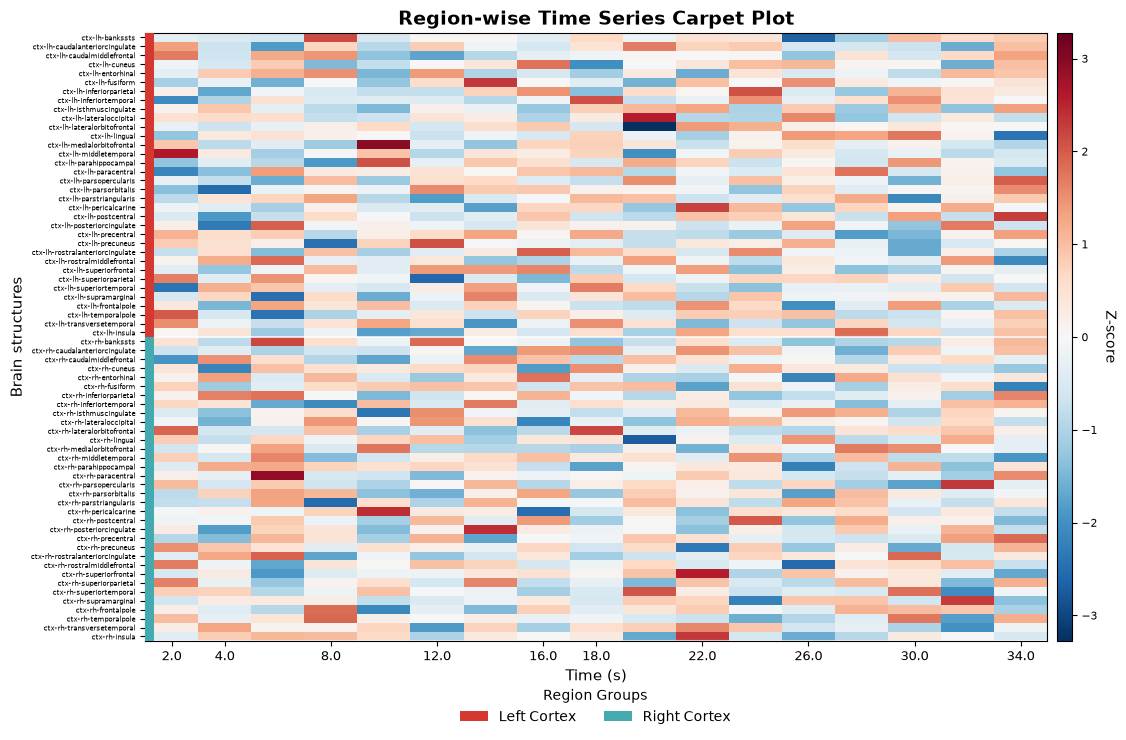

In [3]:
##################### Testing create_carpet_plot ######################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = os.getenv('FREESURFER_HOME', '/opt/freesurfer')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

print("")
print('Computing region-wise time series from file...') 
region_ts = parc.get_regionwise_timeseries(sim_image, method="clabtoolkit", vols_to_delete="1-3", roi_names="ctx")
region_ts.get_info()

print(" ")
print("Test 1: Visualizing the region-wise time series with a carpet plot...")
import clabtoolkit.visualizationtools as cltvis
# Define groups based on region names (e.g., left and right cortex). The rest will remain ungrouped.
groups = {
                "Left Cortex":    ['ctx-lh-'],
                "Right Cortex":   ['ctx-rh-']
            }
cltvis.create_carpet_plot(region_ts, groups=groups, figsize=(12, 8), tr=2.0, title="Region-wise Time Series Carpet Plot", groups_title="Region Groups")
print("-------------------------------")  